In [ ]:
# 1. Créer le dossier caché pour l'API Kaggle
!mkdir -p ~/.kaggle

# 2. Déplacer le fichier de clé API dans le bon dossier
!cp kaggle.json ~/.kaggle/

# 3. Sécuriser le fichier (Kaggle exige cette sécurité)
!chmod 600 ~/.kaggle/kaggle.json

# 4. TÉLÉCHARGER LE DATASET KAGGLE
!kaggle datasets download -d othmanehilal/moroccan-monuments-dataset

# 5. DÉCOMPRESSER LE FICHIER (Le paramètre -q sert à masquer le long texte de décompression)
!unzip -q moroccan-monuments-dataset.zip -d Dataset_Monuments

print("✅ Dataset téléchargé et décompressé directement sur Colab !")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/othmanehilal/moroccan-monuments-dataset
License(s): other
100% 2.96G/2.96G [03:04<00:00, 17.2MB/s]

✅ Dataset téléchargé et décompressé directement sur Colab !


In [ ]:
!ls /content/Dataset_Monuments

dataset


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Rescaling, RandomFlip, RandomRotation
from tensorflow.keras.models import Model
import os

CHEMIN_DATASET = '/content/Dataset_Monuments/dataset'
TAILLE_IMAGE = (224, 224)
BATCH_SIZE = 32

# 1. Chargement (Identique)
train_dataset = image_dataset_from_directory(CHEMIN_DATASET, validation_split=0.2, subset="training", seed=42, image_size=TAILLE_IMAGE, batch_size=BATCH_SIZE)
val_dataset = image_dataset_from_directory(CHEMIN_DATASET, validation_split=0.2, subset="validation", seed=42, image_size=TAILLE_IMAGE, batch_size=BATCH_SIZE)

NOMBRE_CLASSES = len(train_dataset.class_names)
print(f"\n✅ {NOMBRE_CLASSES} Monuments détectés !")

# Optimisation de la RAM Colab
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

print("\n--- Construction du modèle blindé ---")

# A. L'entrée de l'image brute (0-255)
inputs = Input(shape=(224, 224, 3))

# B. LA CORRECTION : On normalise de 0-255 vers -1 à 1 directement dans le réseau !
x = Rescaling(1./127.5, offset=-1)(inputs)

# C. Data Augmentation (Pour rendre l'IA plus robuste aux photos de travers)
x = RandomFlip("horizontal")(x)
x = RandomRotation(0.1)(x)

# D. Le cerveau pré-entraîné
modele_base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
modele_base.trainable = False # On gèle la base
x = modele_base(x, training=False)

# E. La tête de classification
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
predictions = Dense(NOMBRE_CLASSES, activation='softmax')(x)

modele_final = Model(inputs=inputs, outputs=predictions)

# 3. Compilation et Entraînement
modele_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\n--- Début de l'entraînement ---")
historique = modele_final.fit(train_dataset, validation_data=val_dataset, epochs=10)

# 4. Sauvegarde
chemin_sauvegarde = '/content/modele_monuments_robuste.h5'
modele_final.save(chemin_sauvegarde)
print(f"\n✅ Modèle Robuste sauvegardé : {chemin_sauvegarde}")

Found 2001 files belonging to 15 classes.
Using 1601 files for training.
Found 2001 files belonging to 15 classes.
Using 400 files for validation.

✅ 15 Monuments détectés !

--- Construction du modèle blindé ---

--- Début de l'entraînement ---
Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.4266 - loss: 1.9319 - val_accuracy: 0.6775 - val_loss: 1.2060
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.7121 - loss: 0.9591 - val_accuracy: 0.7475 - val_loss: 0.8787
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7983 - loss: 0.7033 - val_accuracy: 0.7925 - val_loss: 0.7486
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8357 - loss: 0.5682 - val_accuracy: 0.8075 - val_loss: 0.6916
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.8576 - loss: 0.4982 - val_accuracy: 0.8200 - val_loss: 0.6385
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8795 - loss: 0.4291 - val_accuracy: 0.8275 - val_loss: 0.610


✅ Modèle Robuste sauvegardé : /content/modele_monuments_robuste.h5


Ordre des classes utilisé par le modèle : 
['Ait Ben Haddou', 'Bab Boujloud', 'Cap Spartel', 'Jemaa el fna', 'La Citerne portugaise El Jadida', 'La mosquee Koutoubia', 'Le Palais El Badi', 'Mausolee Mohammed V', 'Medersa Attarine', 'Medersa Ben Youssef', 'Mosquee Hassan 2', 'Palais Bahia', 'Tannerie Chouara', 'Tombeaux saadiens', 'Volubilis']



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


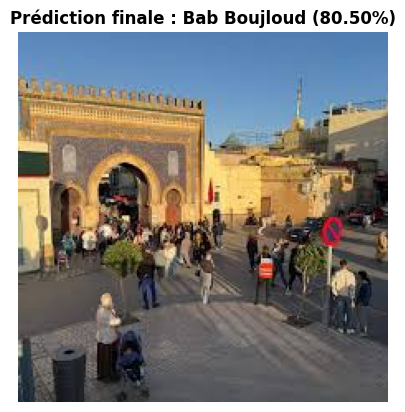


--- DÉTAIL DU TOP 3 (Pour comprendre les doutes du modèle) ---
➡️ Bab Boujloud : 80.50%
➡️ La mosquee Koutoubia : 7.03%
➡️ Palais Bahia : 6.44%


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

# 1. ON RÉCUPÈRE L'ORDRE EXACT DES CLASSES DEPUIS VOS DOSSIERS
CHEMIN_DATASET = '/content/Dataset_Monuments/dataset'
# On liste uniquement les dossiers (pour éviter les fichiers cachés) et on trie par ordre alphabétique
classes_monuments = sorted([d for d in os.listdir(CHEMIN_DATASET) if os.path.isdir(os.path.join(CHEMIN_DATASET, d))])
print(f"Ordre des classes utilisé par le modèle : \n{classes_monuments}\n")

# 2. Charger le modèle
CHEMIN_MODELE = '/content/modele_monuments_robuste.h5'
modele = tf.keras.models.load_model(CHEMIN_MODELE)

# 3. Charger votre image test de Google
CHEMIN_IMAGE_TEST = '/content/bab.jpg' # <-- Mettez le nom de votre photo
img = image.load_img(CHEMIN_IMAGE_TEST, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# 4. Faire la prédiction
predictions = modele.predict(img_array)
index_gagnant = np.argmax(predictions)
monument_trouve = classes_monuments[index_gagnant]
confiance = np.max(predictions) * 100

# 5. Affichage propre avec le Top 3
plt.imshow(img)
plt.axis('off')
plt.title(f"Prédiction finale : {monument_trouve} ({confiance:.2f}%)", fontweight='bold')
plt.show()

print("\n--- DÉTAIL DU TOP 3 (Pour comprendre les doutes du modèle) ---")
top_3_indices = np.argsort(predictions[0])[-3:][::-1]
for i in top_3_indices:
    print(f"➡️ {classes_monuments[i]} : {predictions[0][i]*100:.2f}%")